# <font color='red' size='6'>Inteligência Artificial</font>

## Projeto da Disciplina

### Aplicação de IA para Predição do Risco de AVC – PNS 2019

#### Notebook 2 – Análise exploratória
##### <p><center><b>Grupo</b></center></p>

Marcar com um X a turma a qual o grupo pertence.</br>

<b>Turma: ( &nbsp;&nbsp;&nbsp;&nbsp; )   7G</br> Turma: ( X ) 7N </b><p>
<table width="450" border="2">
    <tr>
        <td><b>Nome do Aluno</b> </td>
        <td><b>RA</b></td>
     </tr>
   <tr>
       <td>Luana Miho Yasuda</td>
       <td>10396439</td>
   </tr>
   <tr>
       <td>Luis Fernando de Mesquita Pereira</td>
       <td>10410686</td>
   </tr>
   <tr>
       <td>Richard Barbosa Sanches</td>
       <td>10420179</td>
   </tr>
   <tr>
       <td>Totti Ferreira Gomes</td>
       <td>10428490</td>
   </tr>
   <tr>
       <td>Gabriel Resende Menezes</td>
       <td>10419003</td>
   </tr>
</table>

## Análise exploratória

Precisa ter rodado o notebook 1 antes, que gera `data/processed/pns2019_avc_40mais.parquet`.

Sobre os pesos: a PNS tem amostragem complexa (estratos, conglomerados e pesos). As prevalências abaixo são
ponderadas pelo peso do morador selecionado, com IC 95% considerando estrato e UPA (`src/pesos.py`). As
distribuições por classe e as correlações são feitas sem peso, porque descrevem a amostra do jeito que o modelo
vai enxergar no treino.

In [2]:
import sys
sys.path.append("..")  # para importar a pasta src

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
import matplotlib.pyplot as plt

from src import pns
from src import graficos as g
from src.pesos import prevalencia, proporcao_ponderada

g.configurar()
pns.DIR_TAB.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(pns.ARQ_BASE)

# versão com rótulo das variáveis 0/1, para as tabelas e gráficos
for col in ["hipertensao", "diabetes", "atividade_fisica", "plano_saude"]:
    df[col + "_rot"] = pd.Categorical(df[col].map({1.0: "Sim", 0.0: "Não"}), categories=["Não", "Sim"], ordered=True)
for col in ["sexo", "cor_raca", "situacao"]:
    df[col] = df[col].astype("category")

print(df.shape)

(54987, 29)


## Variável-alvo e desbalanceamento

In [3]:
n = len(df)
casos = int(df["avc"].sum())
geral = prevalencia(df).iloc[0]

resumo_alvo = pd.DataFrame({
    "indicador": ["Registros (40 anos ou mais)", "Casos de AVC", "Não casos",
                  "Proporção de casos na amostra", "Prevalência ponderada (IC 95%)",
                  "População representada (milhões)", "Negativos para cada positivo"],
    "valor": [f"{n:,}", f"{casos:,}", f"{n - casos:,}", f"{100 * casos / n:.2f}%",
              f"{geral['prevalencia_%']:.2f}% ({geral['ic95_inf_%']:.2f}% a {geral['ic95_sup_%']:.2f}%)",
              f"{geral['populacao_estimada'] / 1e6:.1f}", f"{(n - casos) / casos:.1f}"],
})
resumo_alvo.to_csv(pns.DIR_TAB / "resumo_variavel_alvo.csv", index=False)
resumo_alvo

,indicador,valor
0,Registros (40 anos ou mais),"54,987"
1,Casos de AVC,"1,844"
2,Não casos,"53,143"
3,Proporção de casos na amostra,3.35%
4,Prevalência ponderada (IC 95%),3.20% (2.96% a 3.46%)
5,População representada (milhões),90.6
6,Negativos para cada positivo,28.8


Só 3% da base tem AVC. Um modelo que chutasse "não" para todo mundo acertaria 97% e não serviria para nada, por
isso a acurácia não vai ser a métrica principal: vamos olhar PR-AUC, revocação, precisão e F1, com validação
cruzada estratificada e balanceamento só no treino.

## Prevalência de AVC por subgrupo

In [4]:
subgrupos = {
    "faixa_etaria": "Faixa etária",
    "sexo": "Sexo",
    "cor_raca": "Cor ou raça",
    "regiao": "Região",
    "situacao": "Situação do domicílio",
    "escolaridade_grupo": "Escolaridade",
    "faixa_renda": "Renda domiciliar per capita",
    "plano_saude_rot": "Plano de saúde",
    "hipertensao_rot": "Hipertensão (diagnóstico)",
    "diabetes_rot": "Diabetes (diagnóstico)",
    "imc_categoria": "IMC",
    "tabagismo": "Tabagismo",
    "alcool": "Consumo de álcool",
    "atividade_fisica_rot": "Atividade física (3 meses)",
}

tabs = {col: prevalencia(df, por=col) for col in subgrupos}
prev = pd.concat(tabs.values(), ignore_index=True)
prev["variavel"] = prev["variavel"].map(subgrupos)
prev.to_csv(pns.DIR_TAB / "prevalencia_avc_por_subgrupo.csv", index=False)

prev[["variavel", "categoria", "n", "casos", "prevalencia_%", "ic95_inf_%", "ic95_sup_%"]].style.format(
    {"prevalencia_%": "{:.2f}", "ic95_inf_%": "{:.2f}", "ic95_sup_%": "{:.2f}", "n": "{:,}"}).hide(axis="index")

variavel,categoria,n,casos,prevalencia_%,ic95_inf_%,ic95_sup_%
Faixa etária,40-49,"16,602",202,1.17,0.93,1.47
Faixa etária,50-59,"15,657",371,2.33,1.92,2.81
Faixa etária,60-69,"12,555",515,3.79,3.32,4.33
Faixa etária,70-79,"7,157",504,7.68,6.66,8.83
Faixa etária,80+,"3,016",252,8.50,7.00,10.30
Sexo,Feminino,"29,442",957,3.02,2.72,3.35
Sexo,Masculino,"25,545",887,3.42,3.06,3.83
Cor ou raça,Amarela,413,15,4.07,2.06,7.88
Cor ou raça,Branca,"21,737",667,2.89,2.56,3.26
Cor ou raça,Indígena,407,19,4.06,2.17,7.46


### Idade e sexo

A idade é o que mais pesa: a prevalência sobe a cada década.

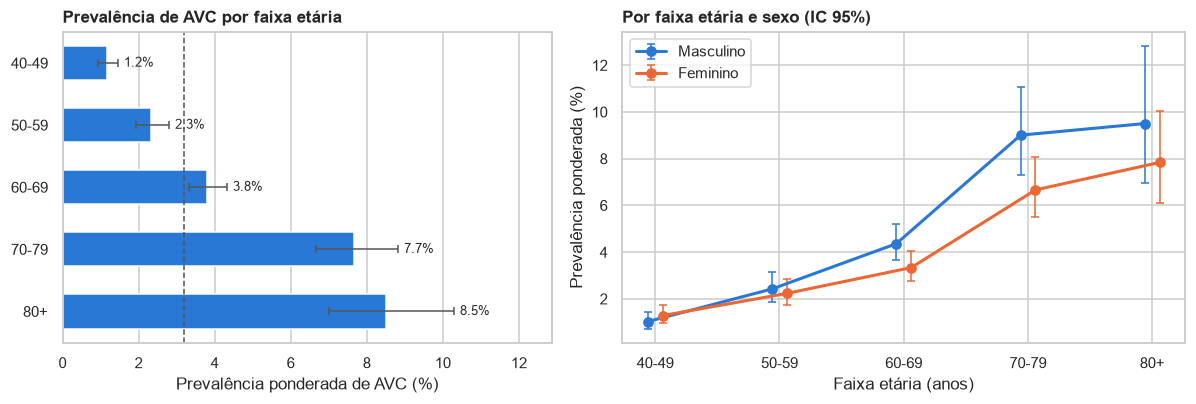

In [5]:
idade_sexo = pd.concat(
    [prevalencia(df[df["sexo"] == s], por="faixa_etaria").assign(sexo=s) for s in ["Masculino", "Feminino"]]
)
idade_sexo.to_csv(pns.DIR_TAB / "prevalencia_avc_idade_sexo.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.15]})
g.barras_prevalencia(axes[0], tabs["faixa_etaria"], "Prevalência de AVC por faixa etária", referencia=geral["prevalencia_%"])

ax = axes[1]
x = np.arange(len(pns.FAIXAS_ETARIAS))
for sexo, cor, desloc in [("Masculino", g.AZUL, -0.06), ("Feminino", g.LARANJA, 0.06)]:
    t = idade_sexo[idade_sexo["sexo"] == sexo]
    ax.errorbar(x + desloc, t["prevalencia_%"],
                yerr=[t["prevalencia_%"] - t["ic95_inf_%"], t["ic95_sup_%"] - t["prevalencia_%"]],
                color=cor, lw=2, marker="o", ms=6, capsize=2.5, elinewidth=1, label=sexo)
ax.set_xticks(x, pns.FAIXAS_ETARIAS)
ax.set_xlabel("Faixa etária (anos)")
ax.set_ylabel("Prevalência ponderada (%)")
ax.set_title("Por faixa etária e sexo (IC 95%)")
ax.legend(loc="upper left")
fig.tight_layout()
g.salvar(fig, "01_prevalencia_idade_sexo")
plt.show()

### Demográficos e socioeconômicos

A linha tracejada é a prevalência geral dos 40+; as barrinhas de erro são o IC 95%.

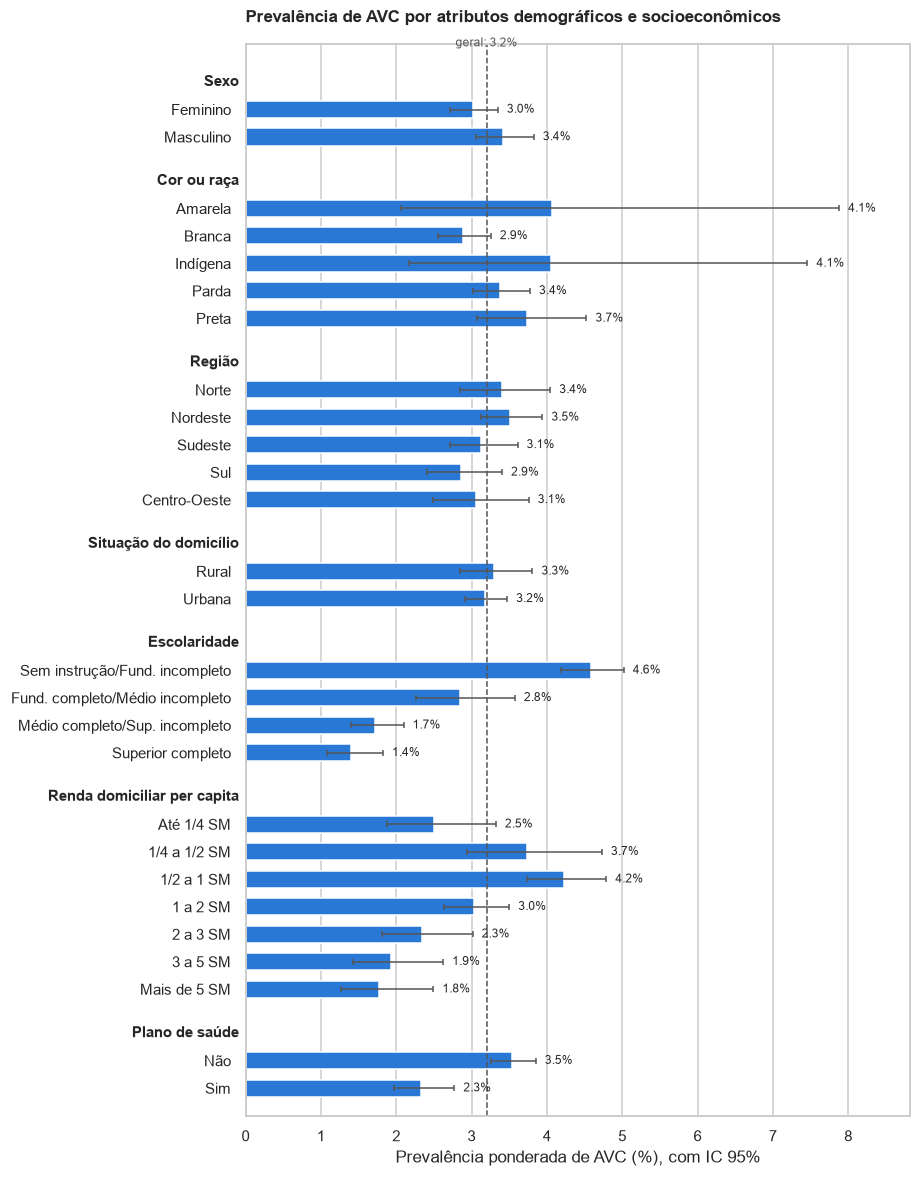

In [6]:
cols = ["sexo", "cor_raca", "regiao", "situacao", "escolaridade_grupo", "faixa_renda", "plano_saude_rot"]
tab = prev[prev["variavel"].isin([subgrupos[c] for c in cols])]
fig = g.prevalencia_agrupada(tab, "Prevalência de AVC por atributos demográficos e socioeconômicos", referencia=geral["prevalencia_%"])
g.salvar(fig, "02_prevalencia_demograficos_socioeconomicos")
plt.show()

### Clínicos e comportamentais

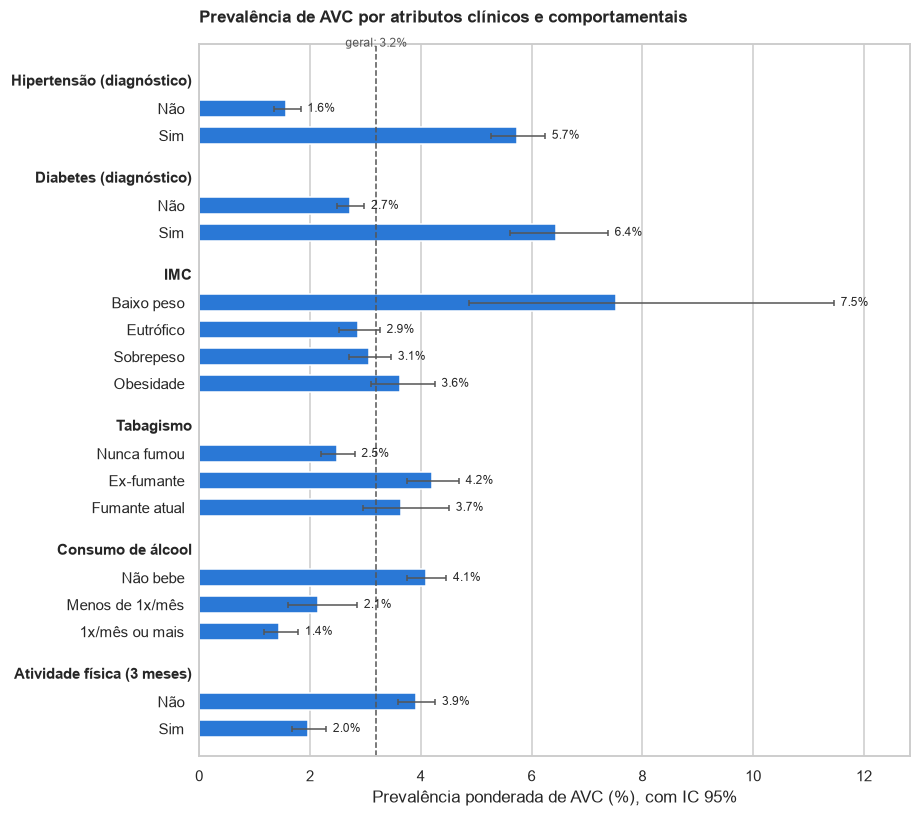

In [7]:
cols = ["hipertensao_rot", "diabetes_rot", "imc_categoria", "tabagismo", "alcool", "atividade_fisica_rot"]
tab = prev[prev["variavel"].isin([subgrupos[c] for c in cols])]
fig = g.prevalencia_agrupada(tab, "Prevalência de AVC por atributos clínicos e comportamentais", referencia=geral["prevalencia_%"])
g.salvar(fig, "03_prevalencia_clinicos_comportamentais")
plt.show()

### Razão de prevalências

Para resumir o tamanho de cada associação, dividimos a prevalência de cada categoria pela de uma categoria de
referência. É uma razão bruta, sem ajustar por idade nem nada: parte do excesso entre hipertensos ou entre quem
tem menos estudo vem do fato desses grupos serem mais velhos.

In [8]:
referencias = {
    "Faixa etária": "40-49", "Sexo": "Feminino", "Cor ou raça": "Branca", "Região": "Sudeste",
    "Situação do domicílio": "Urbana", "Escolaridade": "Superior completo", "Renda domiciliar per capita": "Mais de 5 SM",
    "Plano de saúde": "Sim", "Hipertensão (diagnóstico)": "Não", "Diabetes (diagnóstico)": "Não", "IMC": "Eutrófico",
    "Tabagismo": "Nunca fumou", "Consumo de álcool": "Não bebe", "Atividade física (3 meses)": "Sim",
}
rp = prev.copy()
rp["categoria"] = rp["categoria"].astype(str)
rp["referencia"] = rp["variavel"].map(referencias)
base_ref = rp[rp["categoria"] == rp["referencia"]].set_index("variavel")["prevalencia_%"]
rp["razao"] = rp["prevalencia_%"] / rp["variavel"].map(base_ref)
rp = rp[rp["categoria"] != rp["referencia"]].sort_values("razao", ascending=False)
rp = rp[["variavel", "categoria", "referencia", "prevalencia_%", "razao"]]
rp.to_csv(pns.DIR_TAB / "razao_prevalencia_bruta.csv", index=False)
rp.head(15).style.format({"prevalencia_%": "{:.2f}", "razao": "{:.2f}"}).hide(axis="index")

variavel,categoria,referencia,prevalencia_%,razao
Faixa etária,80+,40-49,8.50,7.28
Faixa etária,70-79,40-49,7.68,6.57
Hipertensão (diagnóstico),Sim,Não,5.74,3.64
Escolaridade,Sem instrução/Fund. incompleto,Superior completo,4.59,3.27
Faixa etária,60-69,40-49,3.79,3.24
IMC,Baixo peso,Eutrófico,7.53,2.62
Renda domiciliar per capita,1/2 a 1 SM,Mais de 5 SM,4.23,2.38
Diabetes (diagnóstico),Sim,Não,6.44,2.36
Renda domiciliar per capita,1/4 a 1/2 SM,Mais de 5 SM,3.74,2.10
Escolaridade,Fund. completo/Médio incompleto,Superior completo,2.85,2.03


## Perfil da amostra por classe

Distribuição (%) ponderada de cada variável entre quem tem e quem não tem AVC.

In [9]:
linhas = []
for col, nome in subgrupos.items():
    total = proporcao_ponderada(df, col)
    sem = proporcao_ponderada(df[df["avc"] == 0], col)
    com = proporcao_ponderada(df[df["avc"] == 1], col)
    for cat in total.index:
        linhas.append({"variavel": nome, "categoria": str(cat), "total_%": total[cat],
                       "sem_avc_%": sem.get(cat, 0.0), "com_avc_%": com.get(cat, 0.0)})
perfil = pd.DataFrame(linhas)
perfil["diferenca_pp"] = perfil["com_avc_%"] - perfil["sem_avc_%"]
perfil.to_csv(pns.DIR_TAB / "perfil_por_classe.csv", index=False)
perfil.style.format({c: "{:.1f}" for c in ["total_%", "sem_avc_%", "com_avc_%", "diferenca_pp"]}).hide(axis="index")

variavel,categoria,total_%,sem_avc_%,com_avc_%,diferenca_pp
Faixa etária,40-49,31.9,32.6,11.7,-20.9
Faixa etária,50-59,30.1,30.4,21.9,-8.5
Faixa etária,60-69,21.4,21.3,25.3,4.1
Faixa etária,70-79,11.4,10.9,27.5,16.5
Faixa etária,80+,5.1,4.9,13.7,8.8
Sexo,Feminino,54.7,54.8,51.6,-3.2
Sexo,Masculino,45.3,45.2,48.4,3.2
Cor ou raça,Amarela,1.0,1.0,1.3,0.3
Cor ou raça,Branca,46.4,46.6,41.9,-4.7
Cor ou raça,Indígena,0.5,0.5,0.7,0.1


## Variáveis numéricas por classe

In [10]:
numericas = ["idade", "imc", "peso", "altura", "renda_per_capita", "escolaridade"]
desc = df.groupby("avc")[numericas].describe().T.unstack(level=1)
desc = desc.rename(columns={0: "sem AVC", 1: "com AVC"}, level=0)
desc.to_csv(pns.DIR_TAB / "estatisticas_numericas_por_classe.csv")
desc.loc[:, (slice(None), ["mean", "std", "25%", "50%", "75%"])]

avc,sem AVC,com AVC,sem AVC,com AVC,sem AVC,com AVC,sem AVC,com AVC,sem AVC,com AVC
,mean,mean,std,std,25%,25%,50%,50%,75%,75%
idade,57.55,66.07,12.11,12.52,48.00,57.00,56.00,66.00,66.00,75.00
imc,26.80,26.82,4.71,4.97,23.60,23.44,26.26,26.34,29.40,29.70
peso,72.07,71.05,14.76,14.52,62.00,61.00,70.00,70.00,80.00,80.00
altura,163.80,162.71,9.53,9.22,157.00,156.00,164.00,163.00,170.00,169.00
renda_per_capita,"1,840.41","1,490.47","3,251.69","2,318.79",600.00,644.75,"1,000.00",998.00,"1,916.00","1,500.00"
escolaridade,3.45,2.71,2.02,1.77,2.00,2.00,2.00,2.00,5.00,3.00


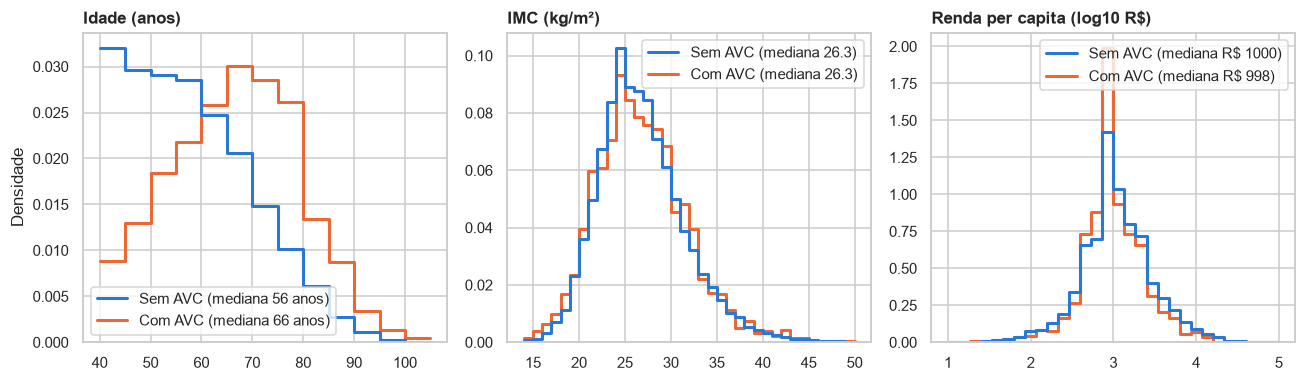

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
g.hist_por_classe(axes[0], df, "idade", "Idade (anos)", bins=13, faixa=(40, 105), fmt="{:.0f} anos")
g.hist_por_classe(axes[1], df, "imc", "IMC (kg/m²)", bins=36, faixa=(14, 50))
g.hist_por_classe(axes[2], df, "renda_per_capita", "Renda per capita (log10 R$)", bins=30, faixa=(1, 5), log=True, fmt="R$ {:.0f}")
for ax in axes[1:]:
    ax.set_ylabel("")
fig.tight_layout()
g.salvar(fig, "04_distribuicao_numericas_por_classe")
plt.show()

## Valores ausentes

Os brancos por pulo do questionário já foram tratados no notebook 1. O que sobra aqui vai ser imputado no
pipeline de modelagem.

In [12]:
ausentes = pd.DataFrame({
    "ausentes_n": df[pns.ATRIBUTOS].isna().sum(),
    "ausentes_%": 100 * df[pns.ATRIBUTOS].isna().mean(),
    "sem_avc_%": 100 * df.loc[df["avc"] == 0, pns.ATRIBUTOS].isna().mean(),
    "com_avc_%": 100 * df.loc[df["avc"] == 1, pns.ATRIBUTOS].isna().mean(),
}).sort_values("ausentes_%", ascending=False)
ausentes.to_csv(pns.DIR_TAB / "valores_ausentes.csv")
algum = df[pns.ATRIBUTOS].isna().any(axis=1)
print(f"registros com algum atributo ausente: {algum.sum()} ({100 * algum.mean():.2f}%)")
ausentes.style.format({"ausentes_%": "{:.3f}", "sem_avc_%": "{:.3f}", "com_avc_%": "{:.3f}"})

registros com algum atributo ausente: 89 (0.16%)


,ausentes_n,ausentes_%,sem_avc_%,com_avc_%
imc,69,0.125,0.130,0.000
peso,68,0.124,0.128,0.000
altura,68,0.124,0.128,0.000
renda_per_capita,14,0.025,0.026,0.000
cor_raca,6,0.011,0.011,0.000
regiao,0,0.000,0.000,0.000
sexo,0,0.000,0.000,0.000
idade,0,0.000,0.000,0.000
diabetes,0,0.000,0.000,0.000
hipertensao,0,0.000,0.000,0.000


## Correlações

As variáveis foram codificadas em números (0/1 para as binárias e a ordem natural para as ordinais) e usamos a
correlação de Spearman, que serve para ordinais e para relações monotônicas não lineares. A primeira coluna
mostra a correlação de cada atributo com o alvo.

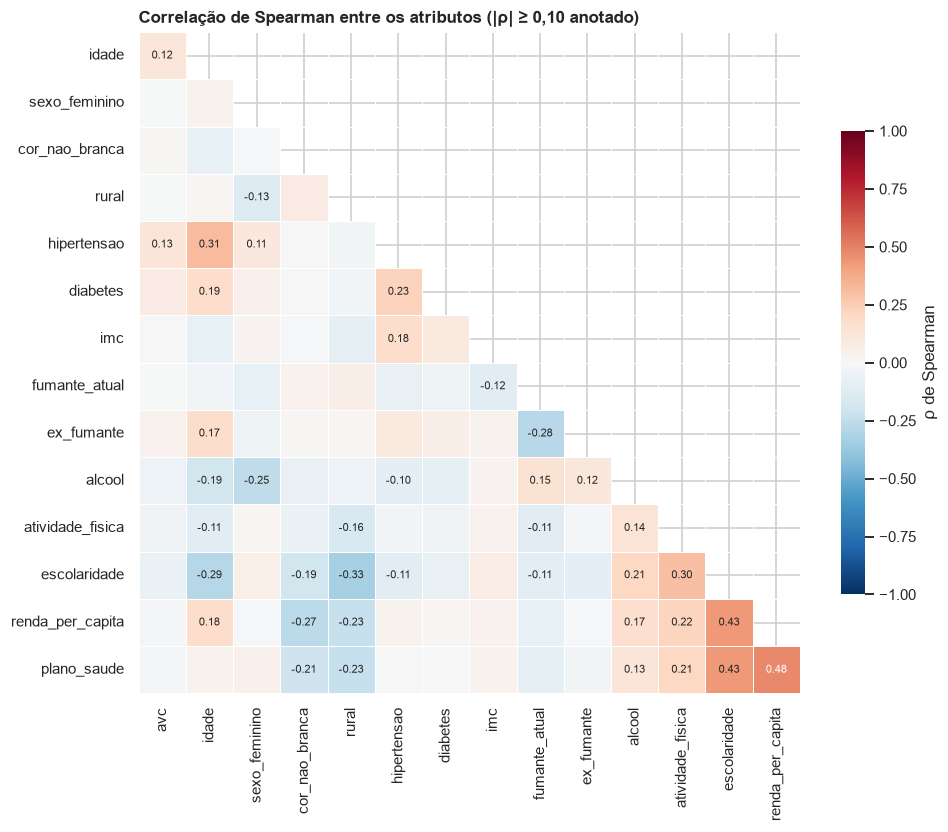

In [13]:
cod = pd.DataFrame({
    "avc": df["avc"],
    "idade": df["idade"],
    "sexo_feminino": (df["sexo"] == "Feminino").astype(int),
    "cor_nao_branca": df["cor_raca"].map(lambda c: np.nan if pd.isna(c) else int(c != "Branca")),
    "rural": (df["situacao"] == "Rural").astype(int),
    "hipertensao": df["hipertensao"],
    "diabetes": df["diabetes"],
    "imc": df["imc"],
    "fumante_atual": (df["tabagismo"] == "Fumante atual").astype(int),
    "ex_fumante": (df["tabagismo"] == "Ex-fumante").astype(int),
    "alcool": df["alcool"].cat.codes.replace(-1, np.nan),
    "atividade_fisica": df["atividade_fisica"],
    "escolaridade": df["escolaridade"],
    "renda_per_capita": df["renda_per_capita"],
    "plano_saude": df["plano_saude"],
})
corr = cod.corr(method="spearman")
corr.to_csv(pns.DIR_TAB / "correlacao_spearman.csv")

fig = g.mapa_correlacao(corr, "Correlação de Spearman entre os atributos (|ρ| ≥ 0,10 anotado)")
g.salvar(fig, "05_correlacao_spearman")
plt.show()

In [14]:
print("correlação com o alvo:")
display(corr["avc"].drop("avc").sort_values(key=abs, ascending=False).to_frame("rho"))

pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().rename("rho").reset_index()
pares.columns = ["atributo_1", "atributo_2", "rho"]
pares = pares[(pares["atributo_1"] != "avc") & (pares["rho"].abs() >= 0.3)].sort_values("rho", key=abs, ascending=False)
print("pares de atributos com |rho| >= 0,30:")
pares

correlação com o alvo:


,rho
hipertensao,0.13
idade,0.12
diabetes,0.08
escolaridade,-0.07
alcool,-0.06
atividade_fisica,-0.05
ex_fumante,0.04
plano_saude,-0.02
renda_per_capita,-0.02
cor_nao_branca,0.01


pares de atributos com |rho| >= 0,30:


,atributo_1,atributo_2,rho
209,renda_per_capita,plano_saude,0.48
193,escolaridade,renda_per_capita,0.43
194,escolaridade,plano_saude,0.43
72,rural,escolaridade,-0.33
20,idade,hipertensao,0.31
177,atividade_fisica,escolaridade,0.30


## O que a análise mostrou

- **Tamanho e desbalanceamento.** 54.987 adultos de 40 anos ou mais, 1.844 com AVC (3,35% da amostra).
  Prevalência ponderada de 3,20% (IC 95%: 2,96% a 3,46%), o que dá uns 2,9 milhões de pessoas. São ~29 negativos
  para cada positivo.
- **Idade.** É o fator mais forte: 1,2% aos 40-49 anos e 8,5% aos 80+ (7 vezes mais). Mediana de 66 anos entre
  os casos e 56 entre os não casos. Depois dos 60 os homens têm prevalência maior (9,0% contra 6,7% aos 70-79),
  mas os IC se sobrepõem.
- **Hipertensão e diabetes.** Hipertensos têm 5,7% contra 1,6% (razão 3,6) e diabéticos 6,4% contra 2,7%
  (razão 2,4). 70% de quem teve AVC é hipertenso, contra 38% de quem não teve. O IMC médio é praticamente igual
  nas duas classes. O grupo de baixo peso tem prevalência alta (7,5%), mas é pequeno (n = 976) e pode ser perda
  de peso depois do AVC.
- **Hábitos e causalidade reversa.** Ex-fumantes (4,2%) e fumantes (3,7%) têm mais AVC do que quem nunca fumou
  (2,5%). Por outro lado, não beber (4,1% contra 1,4%) e não fazer atividade física (3,9% contra 2,0%) aparecem
  ligados a *mais* AVC. Como a PNS é transversal, o mais provável é que a pessoa tenha mudado de hábito ou
  ficado limitada depois do AVC, além do efeito da idade. Não dá para ler isso como álcool protegendo, e isso
  vai ter que ser lembrado na hora de interpretar o SHAP.
- **Escolaridade e renda.** A prevalência cai de 4,6% (sem instrução / fundamental incompleto) para 1,4%
  (superior completo), de 3,5% para 2,3% conforme tem plano de saúde e, no geral, quanto maior a renda (1,8%
  acima de 5 SM). Parte disso é idade: os mais velhos estudaram menos (ρ = -0,29).
- **Região, urbano/rural e cor/raça.** As diferenças entre regiões (2,9% no Sul a 3,5% no Nordeste) e entre
  urbano e rural não são estatisticamente distinguíveis (IC sobrepostos). Pessoas pretas (3,7%) têm um pouco mais
  que brancas (2,9%). Amarela e indígena têm poucos casos e IC muito largos, o que vai limitar a análise por
  subgrupo depois.
- **Ausentes.** Só 89 registros (0,16%) têm algum atributo faltando (peso/altura/IMC 0,12%, renda 0,03%,
  cor/raça 0,01%) e quase não há "ignorado". Imputar pela mediana/moda dentro do pipeline resolve.
- **Correlações.** As correlações com o alvo são todas fracas (|ρ| até 0,13, as maiores são hipertensão e
  idade), o que é normal para um evento raro e mostra que precisa de modelo multivariado. Entre os atributos,
  as maiores são moderadas: renda x plano de saúde (0,48), escolaridade x renda e escolaridade x plano (0,43),
  idade x hipertensão (0,31). Não tem multicolinearidade forte, mas a regressão logística deve ser padronizada
  e regularizada.